# Deep CFR Basics

This notebook starts with a modest game for inspecting the neural APIs, then compares Deep CFR against a saved exact CFR+ run on a shared, larger spec.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'liars_poker').is_dir() and REPO_ROOT.parent != REPO_ROOT:
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from liars_poker.core import GameSpec, possible_starting_hands
from liars_poker.infoset import InfoSet
from liars_poker.policies.neural import NeuralPolicy, compile_neural_to_dense
from liars_poker.algo.br_exact_dense_to_dense import best_response_dense
from liars_poker.algo.deep_cfr import DeepCFRTrainer
from liars_poker.training.deep_cfr import deep_cfr_loop, save_deep_cfr_run, load_deep_cfr_run
from liars_poker.eval.match import eval_seats_split
from liars_poker.policies.random_policy import RandomPolicy
from liars_poker.serialization import load_policy

In [3]:
spec = GameSpec(ranks=4, suits=4, hand_size=2, claim_kinds=("RankHigh", "Pair"), suit_symmetry=True)
opening = InfoSet(pid=0, hand=tuple(possible_starting_hands(spec)[0]), history=())
spec, opening

(GameSpec(ranks=4, suits=4, hand_size=2, claim_kinds=('RankHigh', 'Pair'), suit_symmetry=True),
 InfoSet(pid=0, hand=(1, 1), history=()))

In [5]:
# An untrained NeuralPolicy is uniform over legal actions.
untrained = NeuralPolicy(spec, hidden_sizes=(32, 32))
untrained.action_probs(opening)

{0: 0.125,
 1: 0.125,
 2: 0.125,
 3: 0.125,
 4: 0.125,
 5: 0.125,
 6: 0.125,
 7: 0.125}

In [18]:
trainer_kwargs = {
    'hidden_sizes': (32, 32),
    'advantage_buffer_capacity': 5_000,
    'strategy_buffer_capacity': 5_000,
    'batch_size': 64,
    'advantage_train_steps': 10,
    'strategy_train_steps': 10,
    'seed': 7,
}

avg_policy, logs, trainer = deep_cfr_loop(
    spec,
    iterations=100,
    trainer_kwargs=trainer_kwargs,
    traversals_per_player=50,
    debug=True, eval_every=5
)
logs['training_series'][-1]

[deep-cfr] iter=1 elapsed=0.92s
[deep-cfr] iter=2 elapsed=1.82s
[deep-cfr] iter=3 elapsed=2.56s
[deep-cfr] iter=4 elapsed=3.34s
[deep-cfr] iter=5 elapsed=4.14s
[deep-cfr] iter=6 elapsed=5.03s
[deep-cfr] iter=7 elapsed=6.02s
[deep-cfr] iter=8 elapsed=6.72s
[deep-cfr] iter=9 elapsed=7.49s
[deep-cfr] iter=10 elapsed=8.22s
[deep-cfr] iter=11 elapsed=9.01s
[deep-cfr] iter=12 elapsed=9.79s
[deep-cfr] iter=13 elapsed=10.56s
[deep-cfr] iter=14 elapsed=11.41s
[deep-cfr] iter=15 elapsed=12.33s
[deep-cfr] iter=16 elapsed=13.20s
[deep-cfr] iter=17 elapsed=14.05s
[deep-cfr] iter=18 elapsed=14.90s
[deep-cfr] iter=19 elapsed=15.85s
[deep-cfr] iter=20 elapsed=16.72s
[deep-cfr] iter=21 elapsed=17.58s
[deep-cfr] iter=22 elapsed=18.48s
[deep-cfr] iter=23 elapsed=19.31s
[deep-cfr] iter=24 elapsed=20.17s
[deep-cfr] iter=25 elapsed=21.00s
[deep-cfr] iter=26 elapsed=21.86s
[deep-cfr] iter=27 elapsed=22.77s
[deep-cfr] iter=28 elapsed=23.69s
[deep-cfr] iter=29 elapsed=24.64s
[deep-cfr] iter=30 elapsed=25.53s
[

{'iteration': 100,
 'advantage_loss': [0.6638232469558716, 0.4008060395717621],
 'strategy_loss': [0.7009703516960144, 0.40214502811431885],
 'advantage_buffer_sizes': [5000, 5000],
 'strategy_buffer_sizes': [5000, 5000],
 'elapsed_s': 80.49013079999713}

In [19]:
# Advantage networks define the current regret-matched strategy.
# The returned NeuralPolicy uses the separately trained average-strategy networks.
print('Predicted advantages:', trainer.advantage_values(opening))
print('Current strategy:    ', trainer.current_strategy(opening))
print('Average strategy:    ', avg_policy.action_probs(opening))

Predicted advantages: {0: -0.22120565176010132, 1: -0.2795180082321167, 2: -0.06336560100317001, 3: -0.1559901237487793, 4: 0.11822592467069626, 5: -0.27897608280181885, 6: -0.5780640840530396, 7: -0.863036036491394}
Current strategy:     {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 1.0, 5: 0.0, 6: 0.0, 7: 0.0}
Average strategy:     {0: 0.0011904346756637096, 1: 0.0030153547413647175, 2: 0.007009285502135754, 3: 0.017103200778365135, 4: 0.9515833854675293, 5: 0.017931293696165085, 6: 0.0016832106048241258, 7: 0.00048385935951955616}


In [3]:
# # Dense compilation is for exact evaluation on games small enough to enumerate.
# dense_avg = compile_neural_to_dense(avg_policy)
# _, br_meta = best_response_dense(spec, dense_avg, store_state_values=False)
# p_first, p_second = br_meta['computer'].exploitability()
# print({'p_first': p_first, 'p_second': p_second, 'predicted_avg': 0.5 * (p_first + p_second)})

# # NeuralPolicy can also be used directly by the normal rollout evaluator.
# eval_seats_split(spec, avg_policy, RandomPolicy(), episodes=1_000, seed=7)

In [ ]:
# # Save both artifacts: a lightweight playable policy and the full exact-resume checkpoint.
# run_dir = REPO_ROOT / 'artifacts' / 'deep_cfr_demo'
# save_deep_cfr_run(run_dir, policy=avg_policy, trainer=trainer, logs=logs)

# loaded_policy, loaded_spec = load_policy(str(run_dir / 'policy'))
# loaded_trainer, loaded_metrics = load_deep_cfr_run(run_dir)
# print(type(loaded_policy).__name__, loaded_spec)
# print('Checkpoint iteration:', loaded_trainer.iteration)

# # Exact resume retains networks, optimizers, reservoirs, iteration, and RNG state.
# loaded_trainer.run_iteration(traversals_per_player=10)
# print('After one resumed iteration:', loaded_trainer.iteration)

## Compare Deep CFR with a saved exact CFR+ run

There is no saved CFR/CFR+ run for the introductory `r4_s4_h2_hp` spec. The closest saved run keeps ranks, suits, and hand size identical and adds TwoPair and Trips. To keep the comparison meaningful, Deep CFR is trained below on that saved run's exact spec.

In [13]:
import json

old_run_dir = (
    REPO_ROOT / 'artifacts' / 'benchmark_runs' / 'fsp_runs'
    # / 'r3_s4_h2_hp_ss___20260102-022533'
    / 'r4_s4_h2_hpt_ss___20260102-052328'
)


# C:\Users\adidh\Documents\liars_poker\artifacts\benchmark_runs\fsp_runs\r4_s4_h2_hpt_ss___20260102-052328
old_cfr_plus_logs = json.loads((old_run_dir / 'metrics.json').read_text(encoding='utf-8'))
old_spec_data = json.loads(old_cfr_plus_logs['spec'])
comparison_spec = GameSpec(
    ranks=old_spec_data['ranks'],
    suits=old_spec_data['suits'],
    hand_size=old_spec_data['hand_size'],
    claim_kinds=tuple(old_spec_data['claim_kinds']),
    suit_symmetry=old_spec_data['suit_symmetry'],
)
comparison_spec, len(old_cfr_plus_logs['exploitability_series'])

(GameSpec(ranks=4, suits=4, hand_size=2, claim_kinds=('RankHigh', 'Pair', 'Trips'), suit_symmetry=True),
 10000)

In [ ]:
# Exact evaluation is intentionally periodic: dense compilation and exact BR dominate runtime.
comparison_iterations = 50
comparison_eval_every = 5

deep_comparison_policy, deep_comparison_logs, deep_comparison_trainer = deep_cfr_loop(
    comparison_spec,
    iterations=comparison_iterations,
    trainer_kwargs={
        'hidden_sizes': (64, 64),
        'advantage_buffer_capacity': 20_000,
        'strategy_buffer_capacity': 20_000,
        'batch_size': 128,
        'advantage_train_steps': 20,
        'strategy_train_steps': 20,
        'seed': 9,
    },
    traversals_per_player=50,
    eval_every=comparison_eval_every,
    debug=True,
)
deep_comparison_logs['exploitability_series'][-1]

In [5]:
import matplotlib.pyplot as plt

def plot_exact_exploitability_comparison(series_by_name):
    fig, ax = plt.subplots(figsize=(12, 6))
    for name, logs_for_run in series_by_name.items():
        series = logs_for_run['exploitability_series']
        x = [point.get('iter', i) for i, point in enumerate(series, start=1)]
        y = [2 * point['predicted_avg'] - 1 for point in series]
        ax.plot(x, y, marker='o', markersize=3, label=name)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Training iteration')
    ax.set_ylabel('Exploitability: 2 * predicted_avg - 1')
    ax.set_title(f'Exact exploitability on {comparison_spec.to_short_str()}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return ax

# plot_exact_exploitability_comparison({
#     'saved FSP': old_cfr_plus_logs,
#     'Deep CFR': deep_comparison_logs,
# })

## Small parameter experiment

This holds the network, seed, batch size, buffer capacity, optimizer-step counts, and learning rate fixed. It changes only the number of external-sampling traversals per player and iteration.

Each configuration receives the same Deep CFR training-time budget. Dense compilation and exact best-response evaluation are excluded from that budget.

In [ ]:
from liars_poker.training.deep_cfr import deep_cfr_timed_loop

experiment_training_seconds = 900
experiment_eval_every = 10
shared_trainer_kwargs = {
    'hidden_sizes': (64, 64),
    'batch_size': 128,
    'advantage_buffer_capacity': 20_000,
    'strategy_buffer_capacity': 20_000,
    'advantage_train_steps': 100,
    'strategy_train_steps': 100,
    'learning_rate': 1e-3,
    'seed': 9,
}
experiment_configs = {
    'traversals=25': 25,
    # 'traversals=50': 50,
    # 'traversals=100': 100,
    # 'traversals=200': 200,
}

parameter_sweep_logs = {}
for name, traversals_per_player in experiment_configs.items():
    print(f'\n--- {name} ---')
    _policy, run_logs, _trainer = deep_cfr_timed_loop(
        comparison_spec,
        training_seconds=experiment_training_seconds,
        trainer_kwargs=shared_trainer_kwargs,
        traversals_per_player=traversals_per_player,
        eval_every=experiment_eval_every,
        debug=True,
    )
    parameter_sweep_logs[name] = run_logs

list(parameter_sweep_logs)

In [35]:
import numpy as np
import pandas as pd

summary_rows = []
for name, run_logs in parameter_sweep_logs.items():
    training = run_logs['training_series']
    evaluations = run_logs['exploitability_series']
    last = training[-1]
    total_seen = sum(last['advantage_records_seen']) + sum(last['strategy_records_seen'])
    total_stored = sum(last['advantage_buffer_sizes']) + sum(last['strategy_buffer_sizes'])
    exact_values = [2 * point['predicted_avg'] - 1 for point in evaluations]
    total_training_s = sum(
        point['timing']['traversal_s']
        + point['timing']['advantage_training_s']
        + point['timing']['strategy_training_s']
        for point in training
    )

    summary_rows.append({
        'run': name,
        'final exploitability': exact_values[-1],
        'best exploitability': min(exact_values),
        'iterations completed': last['iteration'],
        'total training min': total_training_s / 60,
        'best exploitability x min': min(exact_values) * total_training_s / 60,
        'mean traversal s': np.mean([point['timing']['traversal_s'] for point in training]),
        'mean advantage fit s': np.mean([point['timing']['advantage_training_s'] for point in training]),
        'mean strategy fit s': np.mean([point['timing']['strategy_training_s'] for point in training]),
        'final advantage loss': np.mean(last['advantage_loss']),
        'final strategy loss': np.mean(last['strategy_loss']),
        'records seen': total_seen,
        'records retained': total_stored,
        'retained fraction': total_stored / total_seen,
    })

parameter_summary = pd.DataFrame(summary_rows).set_index('run')
parameter_summary

,final exploitability,best exploitability,iterations completed,total training min,best exploitability x min,mean traversal s,mean advantage fit s,mean strategy fit s,final advantage loss,final strategy loss,records seen,records retained,retained fraction
run,,,,,,,,,,,,,
traversals=25,0.033037,0.024365,557,14.999873,0.365471,0.159098,0.726988,0.729698,0.315222,0.326798,263949,76262,0.288927


<Axes: title={'center': 'Exact exploitability on r3_s4_h2_hp_ss'}, xlabel='Training iteration', ylabel='Exploitability: 2 * predicted_avg - 1'>

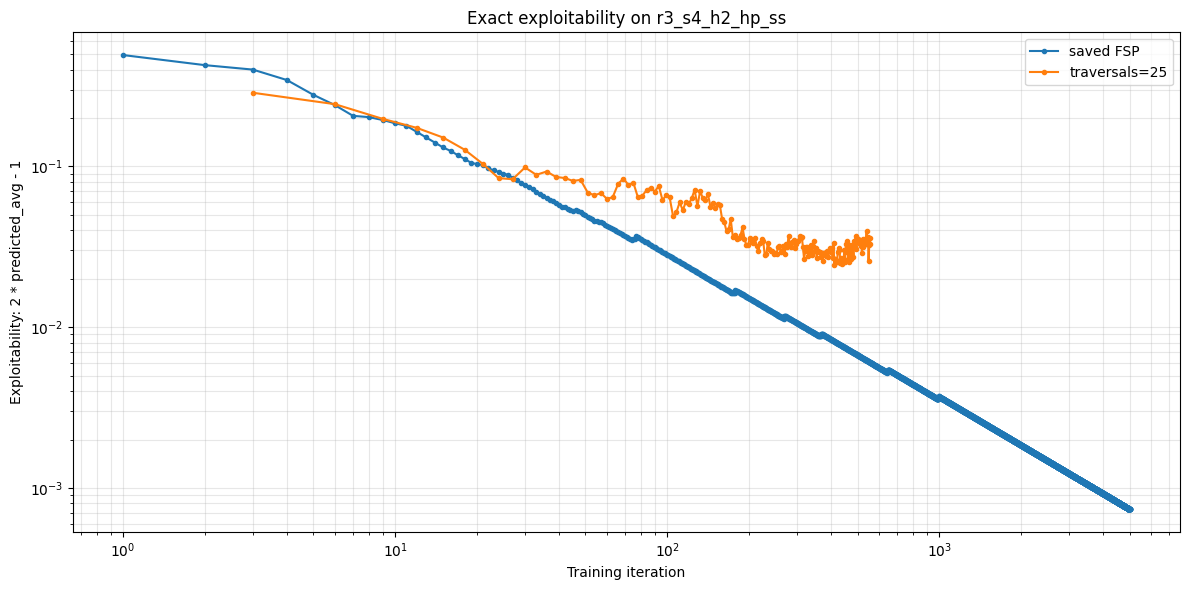

In [34]:
plot_exact_exploitability_comparison({
    'saved FSP': old_cfr_plus_logs,
    **parameter_sweep_logs,
})

## Current versus average strategy

The **current** strategy is regret matching applied directly to the advantage networks. The **average** strategy is represented by the separately fitted strategy networks and is the policy normally returned by Deep CFR. The experiment below also isolates linear versus uniform weighting of strategy-memory records.

In [14]:
from liars_poker.training.deep_cfr import deep_cfr_timed_loop
import pandas as pd
def plot_current_vs_average(logs_by_name, include_fsp=False, include_current=True):
    fig, ax = plt.subplots(figsize=(12, 6))
    if include_fsp:
        series = old_cfr_plus_logs['exploitability_series']
        x = [point.get('iter', i) for i, point in enumerate(series, start=1)]
        y = [max(2 * point['predicted_avg'] - 1, 1e-8) for point in series]
        ax.plot(x, y, marker='o', label='saved FSP')
    for name, run_logs in logs_by_name.items():
        series = run_logs['exploitability_series']
        x = [point['iter'] for point in series]
        average = [max(2 * point['predicted_avg'] - 1, 1e-8) for point in series]

        line, = ax.plot(x, average, marker='o', label=f'{name}: average')
        if include_current:
            current = [max(2 * point['current_predicted_avg'] - 1, 1e-8) for point in series]
            ax.plot(x, current, marker='x', linestyle='--', color=line.get_color(), label=f'{name}: current')
    ax.set(xscale='log', yscale='log', xlabel='Training iteration', ylabel='Exploitability: 2 * predicted_avg - 1')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
    return fig, ax

In [19]:
weighting_training_seconds = 600
weighting_eval_every = 10
weighting_logs = {}

for strategy_weighting in ('linear',):
    print(f'\n--- strategy weighting: {strategy_weighting} ---')
    _policy, run_logs, _trainer = deep_cfr_timed_loop(
        comparison_spec,
        training_seconds=weighting_training_seconds,
        trainer_kwargs={
            'hidden_sizes': (64, 64),
            'batch_size': 128,
            'advantage_buffer_capacity': 50_000,
            'strategy_buffer_capacity': 50_000,
            'advantage_train_steps': 100,
            'strategy_train_steps': 100,
            'learning_rate': 1e-3,
            'strategy_weighting': strategy_weighting,
            'seed': 10,
        },
        traversals_per_player=100,
        eval_every=weighting_eval_every,
        debug=True,
    )
    weighting_logs[strategy_weighting] = run_logs


--- strategy weighting: linear ---
[deep-cfr] iter=1 training_budget=3.92/600.00s traverse=2.53s fit=1.38s
[deep-cfr] iter=2 training_budget=6.93/600.00s traverse=1.69s fit=1.32s
[deep-cfr] iter=3 training_budget=10.19/600.00s traverse=1.87s fit=1.39s
[deep-cfr] iter=4 training_budget=13.51/600.00s traverse=1.96s fit=1.36s
[deep-cfr] iter=5 training_budget=17.38/600.00s traverse=2.32s fit=1.55s
[deep-cfr] iter=6 training_budget=21.70/600.00s traverse=2.98s fit=1.33s
[deep-cfr] iter=7 training_budget=25.82/600.00s traverse=2.76s fit=1.37s
[deep-cfr] iter=8 training_budget=30.05/600.00s traverse=2.88s fit=1.35s
[deep-cfr] iter=9 training_budget=33.76/600.00s traverse=2.33s fit=1.37s
[deep-cfr] iter=10 training_budget=37.45/600.00s traverse=2.30s fit=1.39s
[deep-cfr] iter=11 training_budget=41.02/600.00s traverse=2.20s fit=1.37s
[deep-cfr] iter=12 training_budget=44.37/600.00s traverse=1.89s fit=1.46s
[deep-cfr] iter=13 training_budget=47.85/600.00s traverse=2.01s fit=1.47s
[deep-cfr] it

(<Figure size 1200x600 with 1 Axes>,
 <Axes: xlabel='Training iteration', ylabel='Exploitability: 2 * predicted_avg - 1'>)

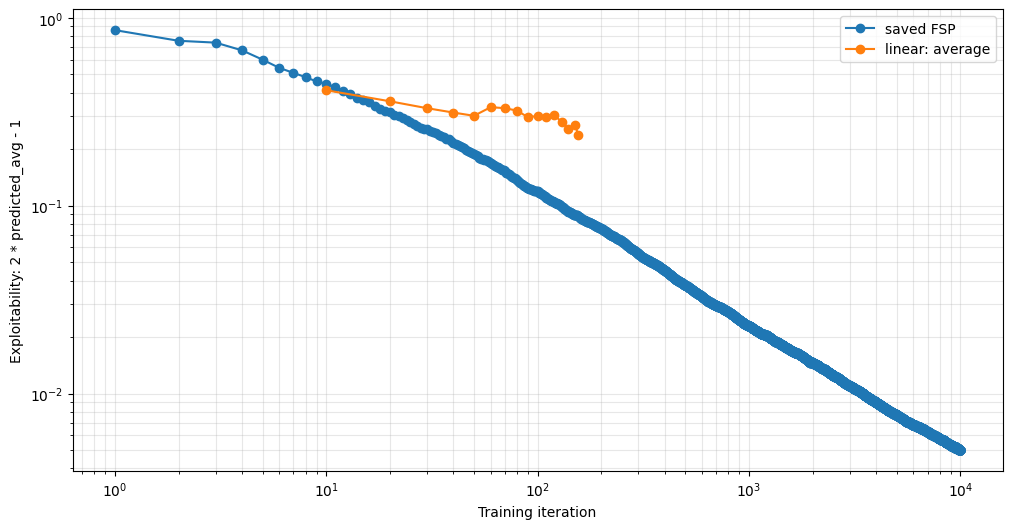

In [20]:
plot_current_vs_average(weighting_logs, include_fsp=True, include_current=False)
# old_cfr_plus_logs['exploitability_series']

In [21]:
pd.DataFrame([
    {
        'strategy weighting': name,
        'final average exploitability': 2 * logs['exploitability_series'][-1]['predicted_avg'] - 1,
        'best average exploitability': min(2 * p['predicted_avg'] - 1 for p in logs['exploitability_series']),
        'final current exploitability': 2 * logs['exploitability_series'][-1]['current_predicted_avg'] - 1,
        'best current exploitability': min(2 * p['current_predicted_avg'] - 1 for p in logs['exploitability_series']),
        'iterations completed': logs['training_series'][-1]['iteration'],
    }
    for name, logs in weighting_logs.items()
]).set_index('strategy weighting')

,final average exploitability,best average exploitability,final current exploitability,best current exploitability,iterations completed
strategy weighting,,,,,
linear,0.23778,0.23778,0.527323,0.417734,156


In [44]:
pd.DataFrame([
    {
        'strategy weighting': name,
        'final average exploitability': 2 * logs['exploitability_series'][-1]['predicted_avg'] - 1,
        'best average exploitability': min(2 * p['predicted_avg'] - 1 for p in logs['exploitability_series']),
        'final current exploitability': 2 * logs['exploitability_series'][-1]['current_predicted_avg'] - 1,
        'best current exploitability': min(2 * p['current_predicted_avg'] - 1 for p in logs['exploitability_series']),
        'iterations completed': logs['training_series'][-1]['iteration'],
    }
    for name, logs in weighting_logs.items()
]).set_index('strategy weighting')

,final average exploitability,best average exploitability,final current exploitability,best current exploitability,iterations completed
strategy weighting,,,,,
linear,0.019138,0.01762,0.035488,-4.816525e-11,1523


## Diagnose neural approximation and averaging

This optional run tracks a truly held-out sample of traversal records and an exact reach-weighted dense average of the neural current strategies. Diagnostic computation is excluded from the timed training budget.

In [22]:
from liars_poker.algo.deep_cfr_diagnostics import ExactDenseStrategyAverager
from liars_poker.training.deep_cfr import deep_cfr_timed_loop
import numpy as np

diagnostic_averager = ExactDenseStrategyAverager(comparison_spec)
diagnostic_policy, diagnostic_logs, diagnostic_trainer = deep_cfr_timed_loop(
    comparison_spec,
    training_seconds=1200,
    exact_averager=diagnostic_averager,
    traversals_per_player=25,
    eval_every=5,
    trainer_kwargs={
        'hidden_sizes': (64, 64),
        'batch_size': 128,
        'advantage_buffer_capacity': 50_000,
        'strategy_buffer_capacity': 50_000,
        'advantage_train_steps': 100,
        'strategy_train_steps': 100,
        'learning_rate': 1e-3,
        'strategy_weighting': 'linear',
        'validation_fraction': 0.05,
        'validation_buffer_capacity': 10_000,
        'seed': 9,
    },
    debug=True,
)

[deep-cfr] iter=1 training_budget=2.20/1200.00s traverse=0.63s fit=1.57s
[deep-cfr] iter=2 training_budget=4.03/1200.00s traverse=0.45s fit=1.37s
[deep-cfr] iter=3 training_budget=6.02/1200.00s traverse=0.56s fit=1.44s
[deep-cfr] iter=4 training_budget=7.90/1200.00s traverse=0.56s fit=1.32s
[deep-cfr] iter=5 training_budget=9.93/1200.00s traverse=0.69s fit=1.34s
[deep-cfr] iter=6 training_budget=12.00/1200.00s traverse=0.66s fit=1.40s
[deep-cfr] iter=7 training_budget=14.01/1200.00s traverse=0.68s fit=1.34s
[deep-cfr] iter=8 training_budget=16.45/1200.00s traverse=0.72s fit=1.72s
[deep-cfr] iter=9 training_budget=18.56/1200.00s traverse=0.71s fit=1.41s
[deep-cfr] iter=10 training_budget=20.69/1200.00s traverse=0.73s fit=1.40s
[deep-cfr] iter=11 training_budget=22.82/1200.00s traverse=0.73s fit=1.40s
[deep-cfr] iter=12 training_budget=24.87/1200.00s traverse=0.63s fit=1.43s
[deep-cfr] iter=13 training_budget=26.84/1200.00s traverse=0.65s fit=1.32s
[deep-cfr] iter=14 training_budget=28.7

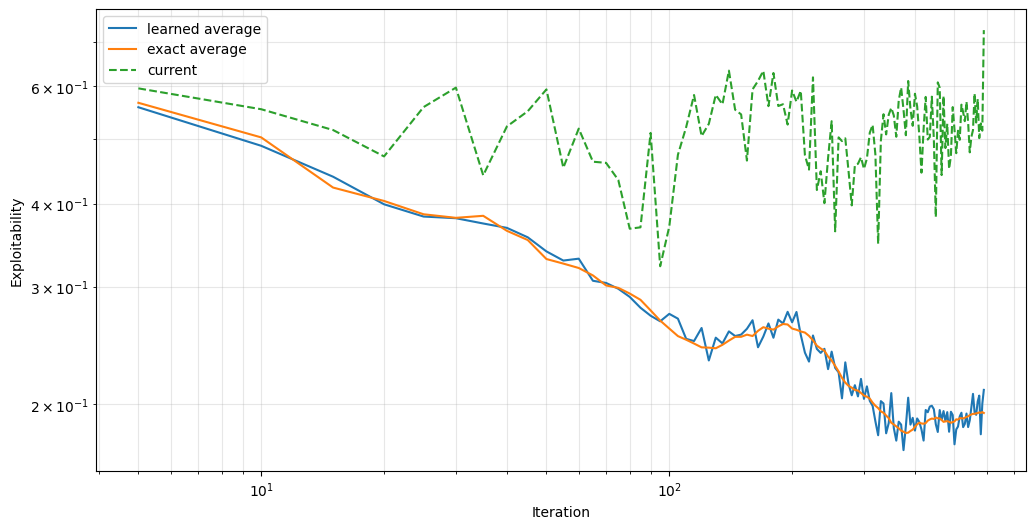

In [23]:
series = diagnostic_logs['exploitability_series']
fig, ax = plt.subplots(figsize=(12, 6))
for key, label, style in [
    ('predicted_avg', 'learned average', '-'),
    ('exact_average_predicted_avg', 'exact average', '-'),
    ('current_predicted_avg', 'current', '--'),
]:
    ax.plot([p['iter'] for p in series], [max(2 * p[key] - 1, 1e-8) for p in series], style, label=label)
ax.set(xscale='log', yscale='log', xlabel='Iteration', ylabel='Exploitability')
ax.grid(True, which='both', alpha=0.3)
ax.legend();

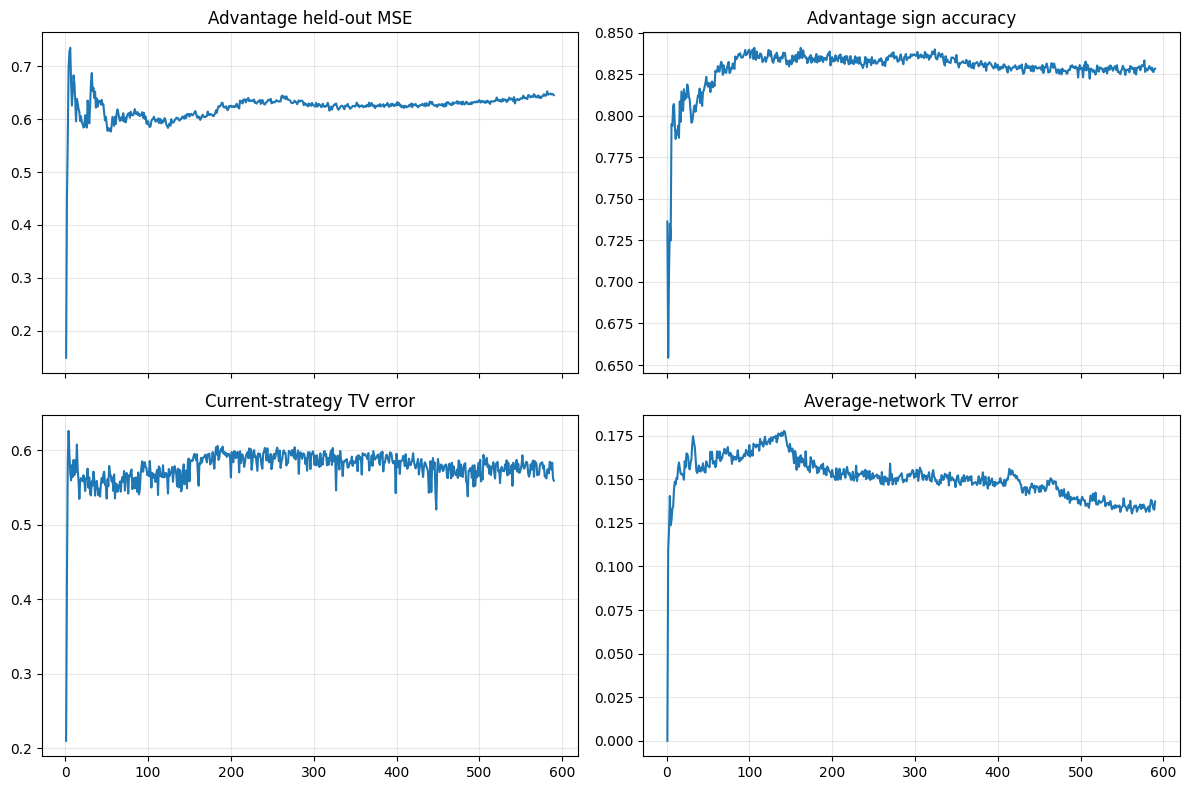

In [24]:
def mean_validation_metric(record, family, key):
    return np.nanmean([player.get(key, np.nan) for player in record['validation'][family]])

training = [record for record in diagnostic_logs['training_series'] if 'validation' in record]
x = [record['iteration'] for record in training]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, family, key, title in [
    (axes[0, 0], 'advantage', 'mse', 'Advantage held-out MSE'),
    (axes[0, 1], 'advantage', 'sign_accuracy', 'Advantage sign accuracy'),
    (axes[1, 0], 'advantage', 'strategy_tv', 'Current-strategy TV error'),
    (axes[1, 1], 'strategy', 'strategy_tv', 'Average-network TV error'),
]:
    ax.plot(x, [mean_validation_metric(record, family, key) for record in training])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
fig.tight_layout();